## AIVLE school 추석 이벤트

### 주제 : 추석전일(22.9.9) 12시 정오 고속도로 서울 TG출발 -> 부산 TG 도착 소요 시간 예측

### 고속도로 공공 데이터 http://data.ex.co.kr/

#### 12~21년도 추석 전일 데이터 수집

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as spst
from sklearn.metrics import *
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('서울-부산통행시간.csv',encoding='cp949')

In [3]:
data.head()

,날짜,출발,도착,시간,도시간 소요시간,서울이용차량,공휴일여부,기온(°C),강수량(mm),풍속(m/s),지면온도(°C)
0,20120929,서울,부산,0,7:56,"8,436",1,15.7,0.0,4.3,13.7
1,20120929,서울,부산,1,8:17,"7,061",1,15.2,0.0,2.5,13.2
2,20120929,서울,부산,2,7:10,"6,370",1,15.1,0.0,2.7,13.3
3,20120929,서울,부산,3,7:55,"7,882",1,14.8,0.0,0.0,13.5
4,20120929,서울,부산,4,7:56,"8,156",1,14.7,0.0,0.0,13.4


In [4]:
data.isna().sum()

날짜          0
출발          0
도착          0
시간          0
도시간 소요시간    0
서울이용차량      0
공휴일여부       0
기온(°C)      0
강수량(mm)     0
풍속(m/s)     0
지면온도(°C)    0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        240 non-null    int64  
 1   출발        240 non-null    object 
 2   도착        240 non-null    object 
 3   시간        240 non-null    int64  
 4   도시간 소요시간  240 non-null    object 
 5   서울이용차량    240 non-null    object 
 6   공휴일여부     240 non-null    int64  
 7   기온(°C)    240 non-null    float64
 8   강수량(mm)   240 non-null    float64
 9   풍속(m/s)   240 non-null    float64
 10  지면온도(°C)  240 non-null    float64
dtypes: float64(4), int64(3), object(4)
memory usage: 20.8+ KB


In [6]:
str(data['날짜'][0])[:4]+"-"+str(data['날짜'][0])[4:6]+"-"+str(data['날짜'][0])[6:]

'2012-09-29'

In [7]:
pd.to_datetime(data['날짜'])

0     1970-01-01 00:00:00.020120929
1     1970-01-01 00:00:00.020120929
2     1970-01-01 00:00:00.020120929
3     1970-01-01 00:00:00.020120929
4     1970-01-01 00:00:00.020120929
                   ...             
235   1970-01-01 00:00:00.020210920
236   1970-01-01 00:00:00.020210920
237   1970-01-01 00:00:00.020210920
238   1970-01-01 00:00:00.020210920
239   1970-01-01 00:00:00.020210920
Name: 날짜, Length: 240, dtype: datetime64[ns]

In [8]:
for i in range(len(data)):
    data['날짜'][i]=str(data['날짜'][i])[:4]+"-"+str(data['날짜'][i])[4:6]+"-"+str(data['날짜'][i])[6:]

<ipython-input-8-23d48474827e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['날짜'][i]=str(data['날짜'][i])[:4]+"-"+str(data['날짜'][i])[4:6]+"-"+str(data['날짜'][i])[6:]
C:\Users\User\anaconda3\lib\site-packages\pandas\core\indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [9]:
data['날짜']=pd.to_datetime(data['날짜'])

In [10]:
data

,날짜,출발,도착,시간,도시간 소요시간,서울이용차량,공휴일여부,기온(°C),강수량(mm),풍속(m/s),지면온도(°C)
0,2012-09-29,서울,부산,0,7:56,"8,436",1,15.7,0.0,4.3,13.7
1,2012-09-29,서울,부산,1,8:17,"7,061",1,15.2,0.0,2.5,13.2
2,2012-09-29,서울,부산,2,7:10,"6,370",1,15.1,0.0,2.7,13.3
3,2012-09-29,서울,부산,3,7:55,"7,882",1,14.8,0.0,0.0,13.5
4,2012-09-29,서울,부산,4,7:56,"8,156",1,14.7,0.0,0.0,13.4
...,...,...,...,...,...,...,...,...,...,...,...
235,2021-09-20,서울,부산,19,4:50,"9,124",0,25.1,0.0,2.7,23.6
236,2021-09-20,서울,부산,20,4:46,"8,889",0,24.9,0.0,2.7,23.6
237,2021-09-20,서울,부산,21,4:24,"8,547",0,24.5,0.0,3.0,23.1
238,2021-09-20,서울,부산,22,4:34,"6,977",0,24.2,0.0,2.9,22.3


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        240 non-null    datetime64[ns]
 1   출발        240 non-null    object        
 2   도착        240 non-null    object        
 3   시간        240 non-null    int64         
 4   도시간 소요시간  240 non-null    object        
 5   서울이용차량    240 non-null    object        
 6   공휴일여부     240 non-null    int64         
 7   기온(°C)    240 non-null    float64       
 8   강수량(mm)   240 non-null    float64       
 9   풍속(m/s)   240 non-null    float64       
 10  지면온도(°C)  240 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(4)
memory usage: 20.8+ KB


In [12]:
int(data['도시간 소요시간'][0][:1])*60+int(data['도시간 소요시간'][0][2:])

476

In [13]:
data['y']=0

In [14]:
import datetime

In [15]:
for i in range(len(data)):
    data['y'][i]=datetime.datetime.strptime(data['도시간 소요시간'][i],"%H:%M").hour*60+datetime.datetime.strptime(data['도시간 소요시간'][i],"%H:%M").minute

<ipython-input-15-beb58b22b5e0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['y'][i]=datetime.datetime.strptime(data['도시간 소요시간'][i],"%H:%M").hour*60+datetime.datetime.strptime(data['도시간 소요시간'][i],"%H:%M").minute


In [16]:
data

,날짜,출발,도착,시간,도시간 소요시간,서울이용차량,공휴일여부,기온(°C),강수량(mm),풍속(m/s),지면온도(°C),y
0,2012-09-29,서울,부산,0,7:56,"8,436",1,15.7,0.0,4.3,13.7,476
1,2012-09-29,서울,부산,1,8:17,"7,061",1,15.2,0.0,2.5,13.2,497
2,2012-09-29,서울,부산,2,7:10,"6,370",1,15.1,0.0,2.7,13.3,430
3,2012-09-29,서울,부산,3,7:55,"7,882",1,14.8,0.0,0.0,13.5,475
4,2012-09-29,서울,부산,4,7:56,"8,156",1,14.7,0.0,0.0,13.4,476
...,...,...,...,...,...,...,...,...,...,...,...,...
235,2021-09-20,서울,부산,19,4:50,"9,124",0,25.1,0.0,2.7,23.6,290
236,2021-09-20,서울,부산,20,4:46,"8,889",0,24.9,0.0,2.7,23.6,286
237,2021-09-20,서울,부산,21,4:24,"8,547",0,24.5,0.0,3.0,23.1,264
238,2021-09-20,서울,부산,22,4:34,"6,977",0,24.2,0.0,2.9,22.3,274


In [17]:
data.corr()

,시간,공휴일여부,기온(°C),강수량(mm),풍속(m/s),지면온도(°C),y
시간,1.000000e+00,1.069241e-17,0.308820,0.097600,0.254961,0.235090,0.247225
공휴일여부,1.069241e-17,1.000000e+00,-0.288544,-0.089594,-0.026889,-0.195627,0.083065
기온(°C),3.088198e-01,-2.885437e-01,1.000000,-0.051993,0.139214,0.856878,0.099171
강수량(mm),9.760047e-02,-8.959415e-02,-0.051993,1.000000,0.030437,-0.053280,-0.052678
풍속(m/s),2.549609e-01,-2.688860e-02,0.139214,0.030437,1.000000,0.208328,0.222192
지면온도(°C),2.350902e-01,-1.956270e-01,0.856878,-0.053280,0.208328,1.000000,0.145455
y,2.472249e-01,8.306521e-02,0.099171,-0.052678,0.222192,0.145455,1.000000


#### 이변량 분석

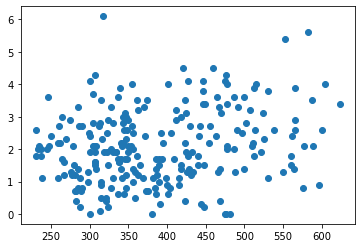

In [18]:
plt.scatter('y','풍속(m/s)',data=data)

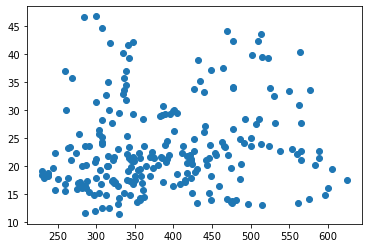

In [19]:
plt.scatter('y','지면온도(°C)',data=data)

In [20]:
spst.pearsonr(data['풍속(m/s)'], data['y'])

(0.2221915962655996, 0.0005250241341784398)

In [21]:
spst.pearsonr(data['지면온도(°C)'], data['y'])

(0.14545525184008584, 0.024220263896066355)

#### 모델링

In [22]:
# 전처리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 모델링
from xgboost import XGBClassifier, plot_tree
from sklearn.metrics import * 
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

import warnings    # 경고메시지 제외
warnings.filterwarnings(action='ignore')

import tensorflow as tf

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [23]:
data['y']=data['y'].shift(-1)

In [24]:
data.dropna(axis=0,inplace=True)

In [25]:
for i in range(len(data)):
    data['서울이용차량'][i]=data['서울이용차량'][i].replace(",","")

In [93]:
data=data.astype({'서울이용차량':'int'})

In [94]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 239 entries, 0 to 238
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        239 non-null    datetime64[ns]
 1   출발        239 non-null    object        
 2   도착        239 non-null    object        
 3   시간        239 non-null    int64         
 4   도시간 소요시간  239 non-null    object        
 5   서울이용차량    239 non-null    int32         
 6   공휴일여부     239 non-null    int64         
 7   기온(°C)    239 non-null    float64       
 8   강수량(mm)   239 non-null    float64       
 9   풍속(m/s)   239 non-null    float64       
 10  지면온도(°C)  239 non-null    float64       
 11  y         239 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int32(1), int64(2), object(3)
memory usage: 31.4+ KB


In [27]:
#data=pd.get_dummies(data,columns=['시간'],drop_first=True)

In [95]:
data

,날짜,출발,도착,시간,도시간 소요시간,서울이용차량,공휴일여부,기온(°C),강수량(mm),풍속(m/s),지면온도(°C),y
0,2012-09-29,서울,부산,0,7:56,8436,1,15.7,0.0,4.3,13.7,497.0
1,2012-09-29,서울,부산,1,8:17,7061,1,15.2,0.0,2.5,13.2,430.0
2,2012-09-29,서울,부산,2,7:10,6370,1,15.1,0.0,2.7,13.3,475.0
3,2012-09-29,서울,부산,3,7:55,7882,1,14.8,0.0,0.0,13.5,476.0
4,2012-09-29,서울,부산,4,7:56,8156,1,14.7,0.0,0.0,13.4,481.0
...,...,...,...,...,...,...,...,...,...,...,...,...
234,2021-09-20,서울,부산,18,5:04,9662,0,25.8,0.0,3.7,25.6,290.0
235,2021-09-20,서울,부산,19,4:50,9124,0,25.1,0.0,2.7,23.6,286.0
236,2021-09-20,서울,부산,20,4:46,8889,0,24.9,0.0,2.7,23.6,264.0
237,2021-09-20,서울,부산,21,4:24,8547,0,24.5,0.0,3.0,23.1,274.0


In [96]:
target = 'y'

x = data.drop([target,'출발','도착','도시간 소요시간','날짜'], axis = 1)
y = data.loc[:, target]

In [97]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size = 30, shuffle = False) #30 : 자연수 - 개수, shuffle : 섞어라 

In [98]:
train_x.shape,test_x.shape

((209, 7), (30, 7))

In [99]:
from sklearn.preprocessing import MinMaxScaler

In [100]:
scaler=MinMaxScaler()

In [101]:
train_x_s=scaler.fit_transform(train_x)
test_x_s=scaler.transform(test_x)

In [102]:
from sklearn.model_selection import TimeSeriesSplit

In [103]:
val_size = 30
nfold = 3

tscv = TimeSeriesSplit(n_splits = nfold, test_size = val_size)
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=30)

##### linear

In [104]:
from sklearn.linear_model import LinearRegression

In [154]:
r2score,rmse, mae, mape = [],[],[],[]
residuals = []
pred = []
model = LinearRegression()

for train_index, val_index in tscv.split(x):

    # 인덱스로 데이터 분할
    x_train, y_train = x.iloc[train_index], y.iloc[train_index]
    x_val, y_val = x.iloc[val_index], y.iloc[val_index]

    # 학습
    model.fit(x_train, y_train)

    # 예측
    pr = model.predict(x_val)
    pred += list(pr)

    # 평가
    r2score.append(r2_score(y_val,pr))
    rmse.append(mean_squared_error(y_val, pr, squared = False))
    mae.append(mean_absolute_error(y_val, pr))
    mape.append(mean_absolute_percentage_error(y_val, pr))

    # 잔차 : 각 fold의 결과를 리스트로 변환하여 추가
    residuals += list(y_val - pr)

np.mean(r2score),np.mean(rmse), np.mean(mae), np.mean(mape)

(-18.151346038297515, 140.84384367544797, 119.74653448720142, 0.39919284453746)

In [155]:
def plot_feature_importance(importance, names, topn = 'all'):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    plt.figure(figsize=(10,8))
    sns.barplot(x='feature_importance', y='feature_names', data = fi_df)

    plt.xlabel('importance')
    plt.ylabel('feature names')
    plt.grid()

    return fi_df

In [156]:
from sklearn.inspection import permutation_importance

In [157]:
pfi1 = permutation_importance(model, x_val, y_val, n_repeats=10, scoring = 'r2', random_state=2022)

In [158]:
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding", 
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

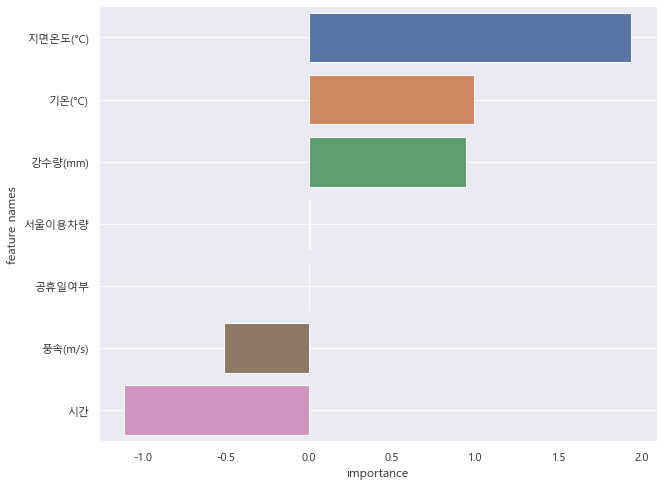

In [159]:
result = plot_feature_importance(pfi1.importances_mean, list(x_train)) #svm 모델의 중요도

In [160]:
#col=['기온(°C)','강수량(mm)','시간_19','지면온도(°C)','시간_10','시간_9','시간_11','시간_7','시간_6','시간_5']
col=['지면온도(°C)','기온(°C)','강수량(mm)']

In [161]:
r2score,rmse, mae, mape = [],[],[],[]
residuals = []
pred = []
model = LinearRegression()

for train_index, val_index in tscv.split(x):

    # 인덱스로 데이터 분할
    x_train, y_train = x.iloc[train_index], y.iloc[train_index]
    x_val, y_val = x.iloc[val_index], y.iloc[val_index]

    # 학습
    model.fit(x_train[col], y_train)

    # 예측
    pr = model.predict(x_val[col])
    pred += list(pr)

    # 평가
    r2score.append(r2_score(y_val,pr))
    rmse.append(mean_squared_error(y_val, pr, squared = False))
    mae.append(mean_absolute_error(y_val, pr))
    mape.append(mean_absolute_percentage_error(y_val, pr))

    # 잔차 : 각 fold의 결과를 리스트로 변환하여 추가
    residuals += list(y_val - pr)

np.mean(r2score),np.mean(rmse), np.mean(mae), np.mean(mape)

(-56.378452183079396,
 189.05015867274554,
 125.2032203256504,
 0.4131192306177818)

In [162]:
n = val_size * nfold
pred = pd.Series(pred, index = y[-n:].index)

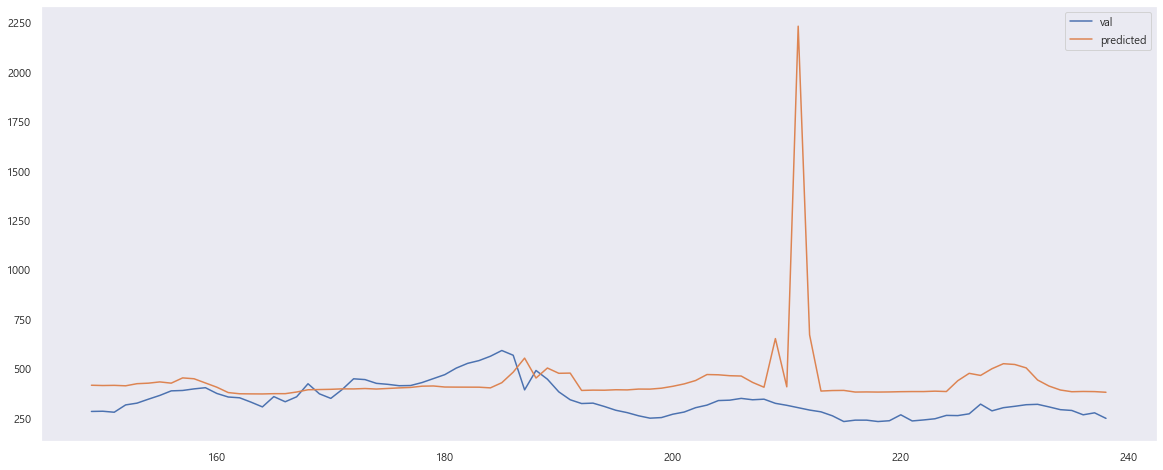

In [163]:

plt.figure(figsize = (20,8))
plt.plot(y[-n:], label = 'val')
plt.plot(pred, label = 'predicted')

plt.legend()
plt.grid()
plt.show()

##### RF

In [164]:
from sklearn.ensemble import RandomForestRegressor

In [167]:
r2score,rmse, mae, mape = [],[],[],[]
residuals = []
pred = []
model = RandomForestRegressor()
params={'n_estimators': range(20,50,5),'max_features':range(1,4,1),'max_depth':range(2,6,1)}

for train_index, val_index in tscv.split(x):

    # 인덱스로 데이터 분할
    x_train, y_train = x.iloc[train_index], y.iloc[train_index]
    x_val, y_val = x.iloc[val_index], y.iloc[val_index]

    # 학습
    model_gs=GridSearchCV(model,params)
    model_gs.fit(x_train, y_train)

    # 예측
    pr = model_gs.predict(x_val)
    pred += list(pr)

    # 평가
    r2score.append(r2_score(y_val,pr))
    rmse.append(mean_squared_error(y_val, pr, squared = False))
    mae.append(mean_absolute_error(y_val, pr))
    mape.append(mean_absolute_percentage_error(y_val, pr))

    # 잔차 : 각 fold의 결과를 리스트로 변환하여 추가
    residuals += list(y_val - pr)

np.mean(r2score),np.mean(rmse), np.mean(mae), np.mean(mape)

(-6.250926710239753, 99.83932221706203, 92.52482472270238, 0.3039576153134182)

In [168]:
model_gs.best_estimator_

RandomForestRegressor(max_depth=2, max_features=3, n_estimators=25)

In [169]:
n = val_size * nfold
pred = pd.Series(pred, index = y[-n:].index)

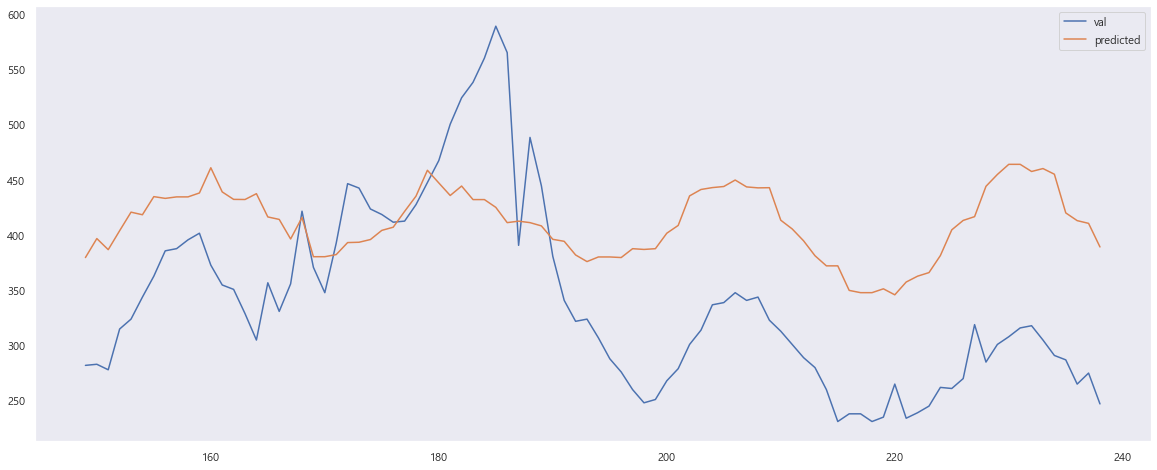

In [170]:

plt.figure(figsize = (20,8))
plt.plot(y[-n:], label = 'val')
plt.plot(pred, label = 'predicted')

plt.legend()
plt.grid()
plt.show()

In [171]:
pfi1 = permutation_importance(model_gs, x_val, y_val, n_repeats=10, scoring = 'r2', random_state=2022)

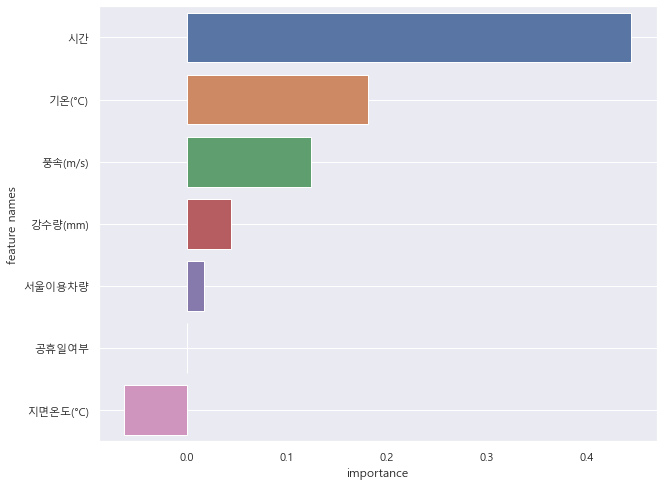

In [172]:
result = plot_feature_importance(pfi1.importances_mean, list(x_train)) 

In [137]:
#col=['시간_16','시간_13','시간_14','시간_17','시간_3','시간_4']
col=['시간','서울이용차량','강수량(mm)','풍속(m/s)','기온(°C)']

In [141]:
r2score,rmse, mae, mape = [],[],[],[]
residuals = []
pred = []
model = RandomForestRegressor()
params={'n_estimators': range(5,30,4),'max_features':range(1,4,1),'max_depth':range(2,6,1)}

for train_index, val_index in tscv.split(x):

    # 인덱스로 데이터 분할
    x_train, y_train = x.iloc[train_index], y.iloc[train_index]
    x_val, y_val = x.iloc[val_index], y.iloc[val_index]

    # 학습
    model_gs=GridSearchCV(model,params)
    model_gs.fit(x_train[col], y_train)

    # 예측
    pr = model_gs.predict(x_val[col])
    pred += list(pr)

    # 평가
    r2score.append(r2_score(y_val,pr))
    rmse.append(mean_squared_error(y_val, pr, squared = False))
    mae.append(mean_absolute_error(y_val, pr))
    mape.append(mean_absolute_percentage_error(y_val, pr))

    # 잔차 : 각 fold의 결과를 리스트로 변환하여 추가
    residuals += list(y_val - pr)

np.mean(r2score),np.mean(rmse), np.mean(mae), np.mean(mape)

(-6.278613299140171, 96.49345403459454, 90.17398850939891, 0.29562469351351434)

In [117]:
x_train.mean()

시간            11.215311
서울이용차량      8765.559809
공휴일여부          0.574163
기온(°C)        21.308134
강수량(mm)        0.021053
풍속(m/s)        2.011962
지면온도(°C)      22.820574
dtype: float64

##### Decision Tree

In [61]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [123]:
r2score,rmse, mae, mape = [],[],[],[]
residuals = []
pred = []
model = DecisionTreeRegressor()
params={'max_depth':range(3,4,1),'min_samples_leaf':range(2,5,1)}

for train_index, val_index in tscv.split(x):

    # 인덱스로 데이터 분할
    x_train, y_train = x.iloc[train_index], y.iloc[train_index]
    x_val, y_val = x.iloc[val_index], y.iloc[val_index]

    # 학습
    
    model_gs=GridSearchCV(model,params)
    model_gs.fit(x_train, y_train)

    # 예측
    pr = model_gs.predict(x_val)
    pred += list(pr)

    # 평가
    r2score.append(r2_score(y_val,pr))
    rmse.append(mean_squared_error(y_val, pr, squared = False))
    mae.append(mean_absolute_error(y_val, pr))
    mape.append(mean_absolute_percentage_error(y_val, pr))

    # 잔차 : 각 fold의 결과를 리스트로 변환하여 추가
    residuals += list(y_val - pr)

np.mean(r2score),np.mean(rmse), np.mean(mae), np.mean(mape)

(-6.483504722683667, 113.7524400881158, 97.89906427884308, 0.3162813933431014)

In [124]:
model_gs.best_estimator_

DecisionTreeRegressor(max_depth=3, min_samples_leaf=4)

In [125]:
pfi1 = permutation_importance(model_gs, x_val, y_val, n_repeats=10, scoring = 'r2', random_state=2022)

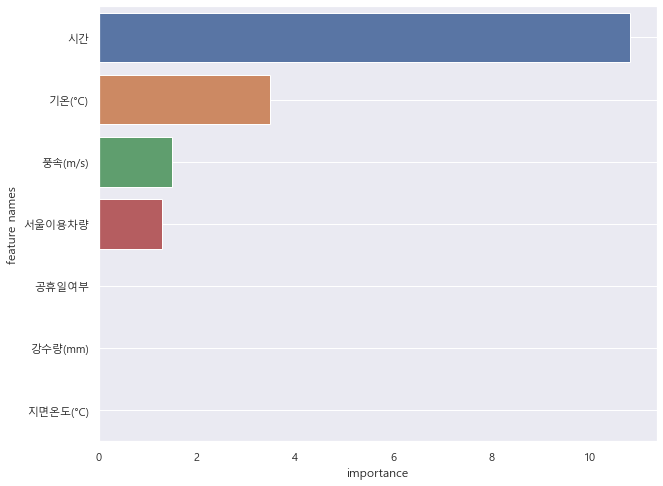

In [126]:
result = plot_feature_importance(pfi1.importances_mean, list(x_train)) 

##### KNN

In [64]:
from sklearn.neighbors import KNeighborsRegressor

In [128]:
r2score,rmse, mae, mape = [],[],[],[]
residuals = []
pred = []
model = KNeighborsRegressor()
params = { 'n_neighbors' : range(40,80,2), 'metric' : ['euclidean', 'manhattan']  }

for train_index, val_index in tscv.split(x):

    # 인덱스로 데이터 분할
    x_train, y_train = x.iloc[train_index], y.iloc[train_index]
    x_val, y_val = x.iloc[val_index], y.iloc[val_index]
    
    scaler=MinMaxScaler()
    x_train_s, x_val_s =scaler.fit_transform(x_train),scaler.transform(x_val)
    
    model_gs=GridSearchCV(model,params)
    
    # 학습
    model_gs.fit(x_train_s, y_train)

    # 예측
    pr = model_gs.predict(x_val_s)
    pred += list(pr)

    # 평가
    r2score.append(r2_score(y_val,pr))
    rmse.append(mean_squared_error(y_val, pr, squared = False))
    mae.append(mean_absolute_error(y_val, pr))
    mape.append(mean_absolute_percentage_error(y_val, pr))

    # 잔차 : 각 fold의 결과를 리스트로 변환하여 추가
    residuals += list(y_val - pr)

np.mean(r2score),np.mean(rmse), np.mean(mae), np.mean(mape)

(-6.525570958519178, 97.32770284210524, 90.14985754985753, 0.3013091830117033)

In [129]:
model_gs.best_estimator_

KNeighborsRegressor(metric='manhattan', n_neighbors=78)

##### 예측시간

In [174]:
 model_gs.predict([[12,8765,0,27,0.2,2,0.2]])
#model_gs.predict([[12,8765,0,2.0,27]])

array([414.03914217])

6시간 13분?